 Part 2: CNN Computer Vision

 Task 1: Problem Identification

This dataset represents an Image Classification problem.

Reason:
The dataset contains images divided into four categories:
- dent
- normal
- scratch
- stain

The CNN model learns to classify an image into one of these classes.

In [5]:
import os

dataset_path = "dataset"

classes = os.listdir(dataset_path)

print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['dent', 'normal', 'scratch', 'stain']
Number of classes: 4


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

 Task 2: Dataset Exploration

In [7]:
for class_name in classes:
    
    class_path = os.path.join(dataset_path, class_name)
    
    num_images = len(os.listdir(class_path))
    
    print(f"{class_name}: {num_images} images")

dent: 120 images
normal: 120 images
scratch: 120 images
stain: 120 images


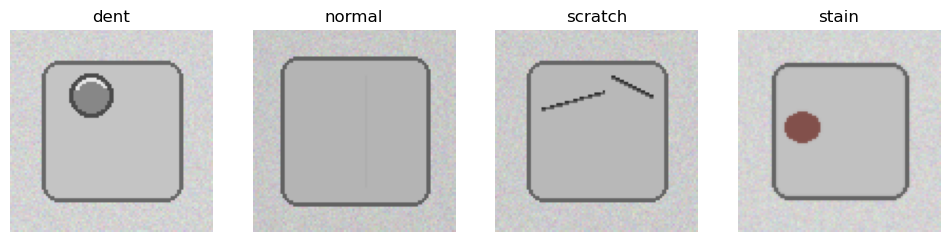

In [8]:
plt.figure(figsize=(12,5))

for i, class_name in enumerate(classes):
    
    class_path = os.path.join(dataset_path, class_name)
    
    image_name = os.listdir(class_path)[0]
    
    image_path = os.path.join(class_path, image_name)
    
    image = Image.open(image_path)
    
    plt.subplot(1, len(classes), i+1)
    
    plt.imshow(image)
    
    plt.title(class_name)
    
    plt.axis("off")

plt.show()

In [9]:
for class_name in classes:
    
    class_path = os.path.join(dataset_path, class_name)
    
    image_name = os.listdir(class_path)[0]
    
    image_path = os.path.join(class_path, image_name)
    
    image = Image.open(image_path)
    
    print(class_name, image.size)

dent (96, 96)
normal (96, 96)
scratch (96, 96)
stain (96, 96)


 Task 3: Image Preprocessing

In [10]:
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [11]:
IMG_SIZE = 128

BATCH_SIZE = 32

In [12]:
datagen = ImageDataGenerator(
    
    rescale=1./255,
    
    validation_split=0.2,
    
    rotation_range=20,
    
    zoom_range=0.2,
    
    horizontal_flip=True
)

In [13]:
train_data = datagen.flow_from_directory(
    
    dataset_path,
    
    target_size=(IMG_SIZE, IMG_SIZE),
    
    batch_size=BATCH_SIZE,
    
    class_mode='categorical',
    
    subset='training'
)

Found 384 images belonging to 4 classes.


In [14]:
val_data = datagen.flow_from_directory(
    
    dataset_path,
    
    target_size=(IMG_SIZE, IMG_SIZE),
    
    batch_size=BATCH_SIZE,
    
    class_mode='categorical',
    
    subset='validation'
)

Found 96 images belonging to 4 classes.


Task 4: CNN Model Creation

In [15]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [16]:
model = Sequential()

# First Convolution Layer
model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(128,128,3)
))

# First Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

# Second Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(
    128,
    activation='relu'
))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(
    len(classes),
    activation='softmax'
))

c:\Users\sampe\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

Task 5: Model Training and Evaluation

In [19]:
history = model.fit(
    
    train_data,
    
    validation_data=val_data,
    
    epochs=10
)

c:\Users\sampe\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 539ms/step - accuracy: 0.2874 - loss: 2.9293 - val_accuracy: 0.2500 - val_loss: 1.3812
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 393ms/step - accuracy: 0.2980 - loss: 1.3775 - val_accuracy: 0.4167 - val_loss: 1.3572
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 449ms/step - accuracy: 0.4144 - loss: 1.3314 - val_accuracy: 0.2500 - val_loss: 1.2979
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 343ms/step - accuracy: 0.3925 - loss: 1.2681 - val_accuracy: 0.5000 - val_loss: 1.1467
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 455ms/step - accuracy: 0.5528 - loss: 1.1460 - val_accuracy: 0.6771 - val_loss: 0.9475
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 389ms/step - accuracy: 0.6611 - loss: 0.8765 - val_accuracy: 0.7708 - val_loss: 0.7478
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 367ms/step - accuracy: 0.6879 - loss: 0.7648 - val_accuracy: 0.8646 - val_loss: 0.6332
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 353ms/step - accuracy: 0.6834 - loss: 0.6987 - val_accuracy: 0.

In [20]:
history = model.fit(
    
    train_data,
    
    validation_data=val_data,
    
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.8114 - loss: 0.5267 - val_accuracy: 0.9062 - val_loss: 0.3551
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.8408 - loss: 0.4264 - val_accuracy: 0.9062 - val_loss: 0.3745
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 79s 7s/step - accuracy: 0.8883 - loss: 0.3716 - val_accuracy: 0.8958 - val_loss: 0.4034
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - accuracy: 0.8450 - loss: 0.4060 - val_accuracy: 0.9167 - val_loss: 0.3024
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.8697 - loss: 0.3376 - val_accuracy: 0.9271 - val_loss: 0.2461
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - accuracy: 0.8891 - loss: 0.3025 - val_accuracy: 0.9167 - val_loss: 0.2854
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.8591 - loss: 0.3971 - val_accuracy: 0.9688 - val_loss: 0.2190
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 61s 4s/step - accuracy: 0.9143 - loss: 0.2644 - val_accuracy: 0.9167 - val_loss:

In [21]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [22]:
import os

dataset_path = "dataset"

classes = os.listdir(dataset_path)

print(classes)

['dent', 'normal', 'scratch', 'stain']


In [23]:
model = Sequential()

# First Convolution Layer
model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(128,128,3)
))

# First Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

# Second Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(
    128,
    activation='relu'
))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(
    len(classes),
    activation='softmax'
))

In [24]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 66s 4s/step - accuracy: 0.2532 - loss: 5.0683 - val_accuracy: 0.2500 - val_loss: 1.3863
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.2399 - loss: 1.3922 - val_accuracy: 0.4167 - val_loss: 1.3795
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 867ms/step - accuracy: 0.3132 - loss: 1.3769 - val_accuracy: 0.5417 - val_loss: 1.3649
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 936ms/step - accuracy: 0.3454 - loss: 1.3656 - val_accuracy: 0.4896 - val_loss: 1.3635
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 936ms/step - accuracy: 0.4992 - loss: 1.3676 - val_accuracy: 0.3958 - val_loss: 1.3517
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 690ms/step - accuracy: 0.4814 - loss: 1.3188 - val_accuracy: 0.4896 - val_loss: 1.3211
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 393ms/step - accuracy: 0.5019 - loss: 1.3053 - val_accuracy: 0.5312 - val_loss: 1.2498
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 316ms/step - accuracy: 0.4684 - loss: 1.2168 - val_accuracy: 0.5

In [26]:
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [27]:
IMG_SIZE = 128

BATCH_SIZE = 32

In [28]:
datagen = ImageDataGenerator(
    
    rescale=1./255,
    
    validation_split=0.2,
    
    rotation_range=20,
    
    zoom_range=0.2,
    
    horizontal_flip=True
)

In [29]:
train_data = datagen.flow_from_directory(
    
    dataset_path,
    
    target_size=(IMG_SIZE, IMG_SIZE),
    
    batch_size=BATCH_SIZE,
    
    class_mode='categorical',
    
    subset='training'
)

Found 384 images belonging to 4 classes.


In [30]:
val_data = datagen.flow_from_directory(
    
    dataset_path,
    
    target_size=(IMG_SIZE, IMG_SIZE),
    
    batch_size=BATCH_SIZE,
    
    class_mode='categorical',
    
    subset='validation'
)

Found 96 images belonging to 4 classes.


In [31]:
history = model.fit(
    
    train_data,
    
    validation_data=val_data,
    
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 752ms/step - accuracy: 0.5538 - loss: 1.0593 - val_accuracy: 0.6667 - val_loss: 1.0140
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 694ms/step - accuracy: 0.6067 - loss: 0.9656 - val_accuracy: 0.4792 - val_loss: 1.0115
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 667ms/step - accuracy: 0.6019 - loss: 0.9682 - val_accuracy: 0.6146 - val_loss: 0.9123
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 663ms/step - accuracy: 0.5804 - loss: 0.8669 - val_accuracy: 0.6354 - val_loss: 0.9106
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 667ms/step - accuracy: 0.6224 - loss: 0.8560 - val_accuracy: 0.6458 - val_loss: 0.8355
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 672ms/step - accuracy: 0.6909 - loss: 0.8067 - val_accuracy: 0.6771 - val_loss: 0.7853
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 400ms/step - accuracy: 0.6615 - loss: 0.8222 - val_accuracy: 0.7604 - val_loss: 0.7472
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 327ms/step - accuracy: 0.7040 - loss: 0.7152 - val_accuracy: 0.

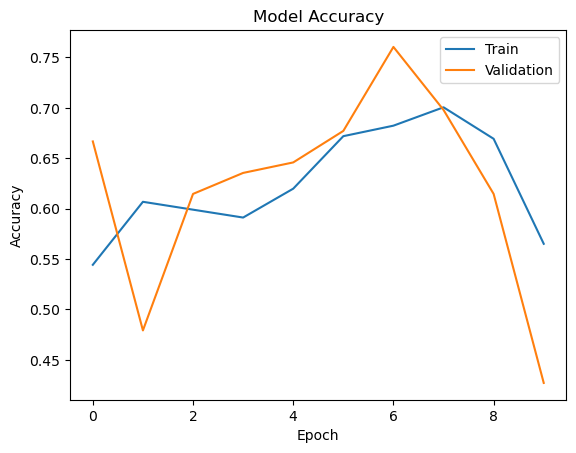

In [32]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.savefig("results/accuracy_loss_curves.png")

plt.show()

In [33]:
import matplotlib.pyplot as plt

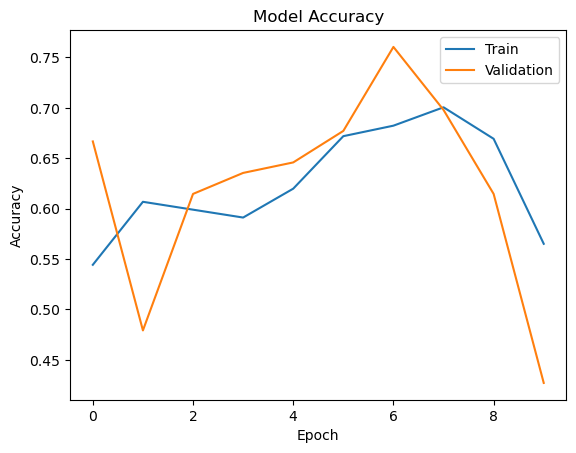

In [34]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.savefig("results/accuracy_loss_curves.png")

plt.show()

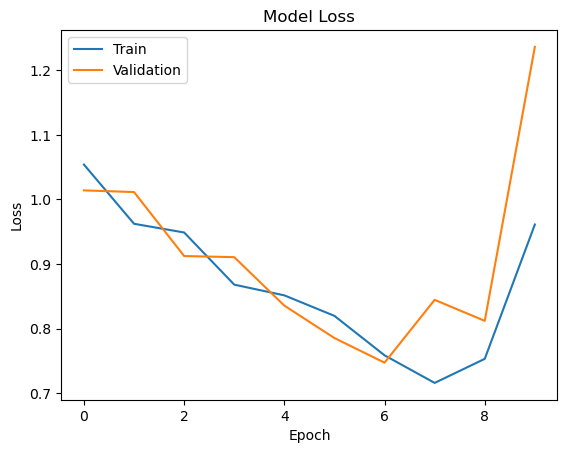

In [35]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

In [36]:
test_loss, test_accuracy = model.evaluate(val_data)

print("Test Accuracy:", test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step - accuracy: 0.4505 - loss: 1.2292
Test Accuracy: 0.4479166567325592


In [37]:
from sklearn.metrics import confusion_matrix

import seaborn as sns

In [38]:
predictions = model.predict(val_data)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = val_data.classes

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 223ms/step


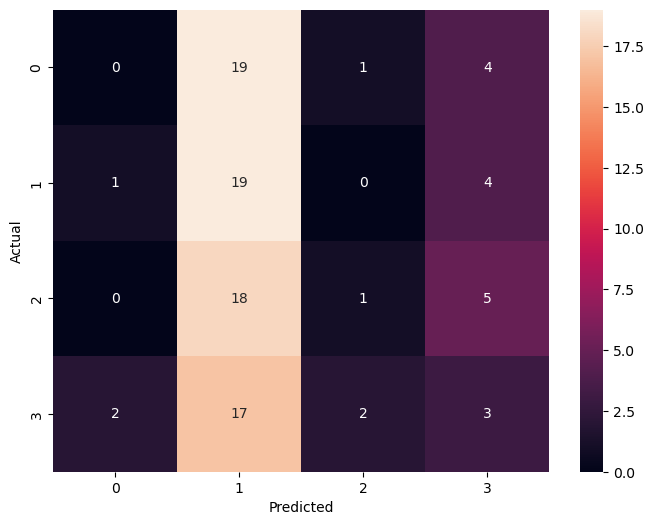

In [39]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig("results/confusion_matrix.png")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step


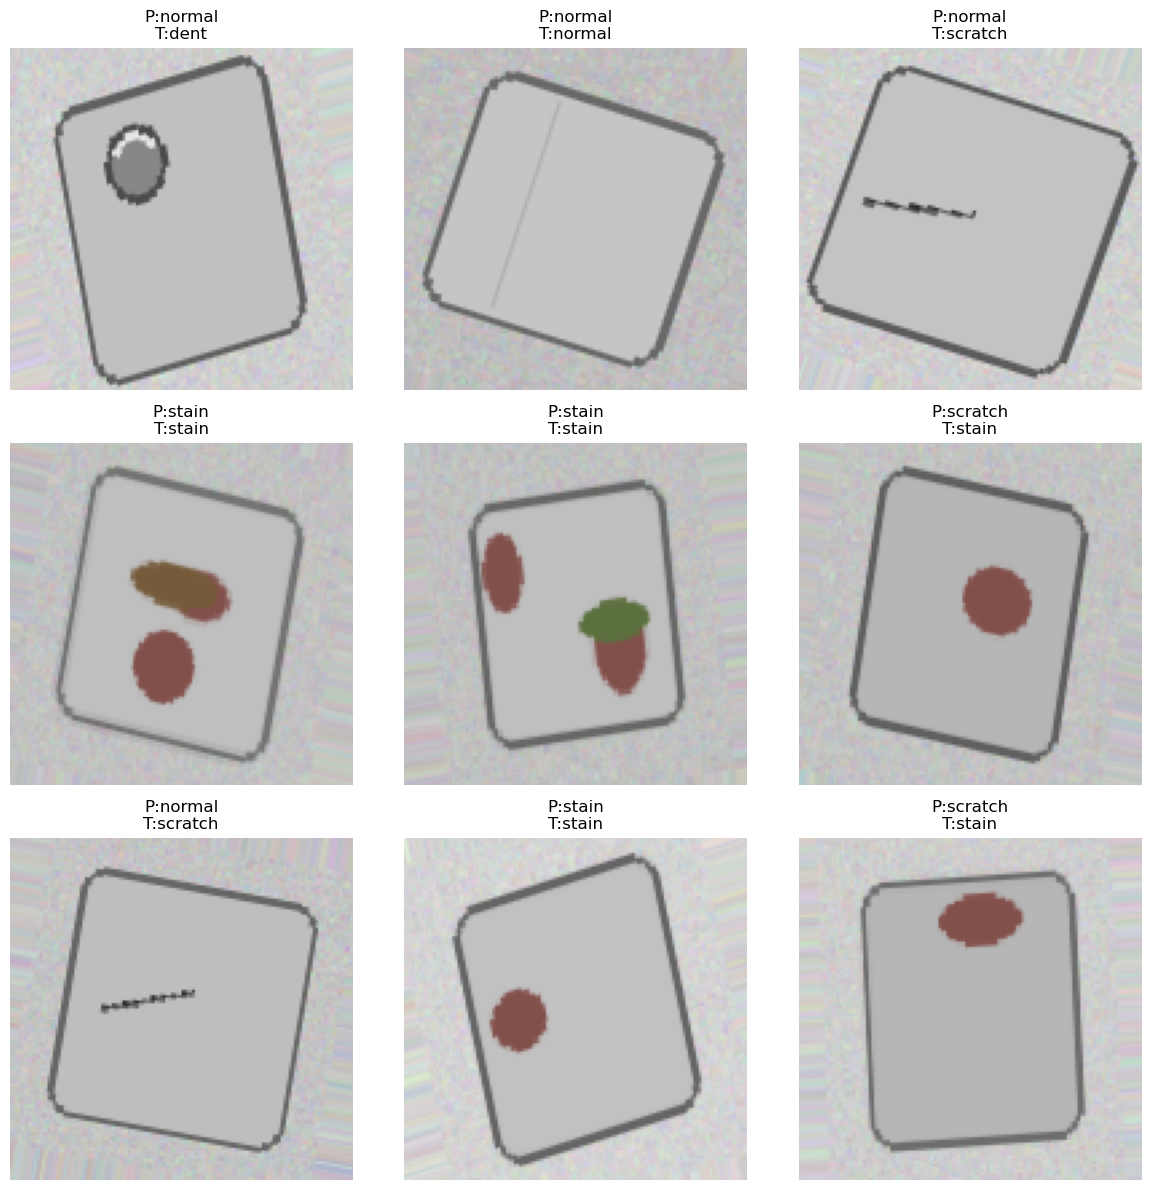

In [40]:
images, labels = next(val_data)

preds = model.predict(images)

plt.figure(figsize=(12,12))

for i in range(9):
    
    plt.subplot(3,3,i+1)
    
    plt.imshow(images[i])
    
    predicted_label = classes[np.argmax(preds[i])]
    
    true_label = classes[np.argmax(labels[i])]
    
    plt.title(f"P:{predicted_label}\nT:{true_label}")
    
    plt.axis("off")

plt.tight_layout()

plt.savefig("sample_predictions/prediction_outputs.png")

plt.show()